# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [4]:
# Carga de librerias, las que hemos considerado basicas, anadid lo que querais :)
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (accuracy_score, silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score,
                             normalized_mutual_info_score)
from scipy.cluster.hierarchy import linkage, dendrogram
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# Rutas relativas al notebook: funcionan desde cualquier cwd y crean los directorios.
from pathlib import Path
BASE_DIR = Path.cwd().parent
DATA_CLEANED = BASE_DIR / 'data' / 'cleaned'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
DATA_CLEANED.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

### Leer conjunto de datos y primer vistazo

In [5]:
df = pd.read_csv('../data/raw/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [6]:
# Descripcion del conjunto de datos, estandar.
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [7]:
# Informacion sobre el tipo de datos de cada feature.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

#### Calcular el número de nulos de cada feature

In [8]:
# Igual que otras veces, una linea: contar los nulos por variable.
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [9]:
# Obtener un nuevo dataframe: en una columna las features (feature)
# y en la otra el numero de valores unicos asociados (n_values).
n_values = pd.DataFrame({'feature': df.columns, 'n_values': df.nunique().values})
n_values

,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [10]:
# Imputaciones. Podeis quitar esos puntos (fila entera), imputar con la moda
# o dejar ese valor como una posibilidad mas. Aqui imputamos '?' con la moda.
for col in df.columns:
    if '?' in df[col].values:
        moda = df[col].mode()[0]
        df[col] = df[col].replace('?', moda)

df['stalk-root'].value_counts()

stalk-root
b    6256
e    1120
c     556
r     192
Name: count, dtype: int64

#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [11]:
# Dejar por el camino las features con un solo valor (no aportan nada).
df = df.loc[:, df.nunique() > 1]
print(f"Columnas tras eliminar las constantes: {df.shape[1]}")

# Guardamos el dataset limpio para reutilizarlo en fases posteriores
df.to_parquet(DATA_CLEANED / 'mushrooms_cleaned.parquet')

Columnas tras eliminar las constantes: 22


#### Separar entre variables predictoras y variable a predecir

In [12]:
# La variable a predecir es 'class'.
y = df['class']
X = df.drop('class', axis=1)

# Codificamos la etiqueta para poder usar ARI/NMI mas adelante
y_bin = (y == 'p').astype(int)

#### Codificar correctamente las variables categóricas a numéricas

In [13]:
# One Hot Encoder (una linea). Pista: pd.get_dummies
X = pd.get_dummies(X)
print(f"Dimensiones tras el One-Hot Encoding: {X.shape}")

# Guardamos el dataset ya codificado para reutilizarlo en fases posteriores
X.to_parquet(DATA_PROCESSED / 'mushrooms_encoded.parquet')

Dimensiones tras el One-Hot Encoding: (8124, 115)


#### Train / test split

In [14]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

Text(0.5, 1.0, 'Proyección PCA (2 componentes) coloreada por la etiqueta real')

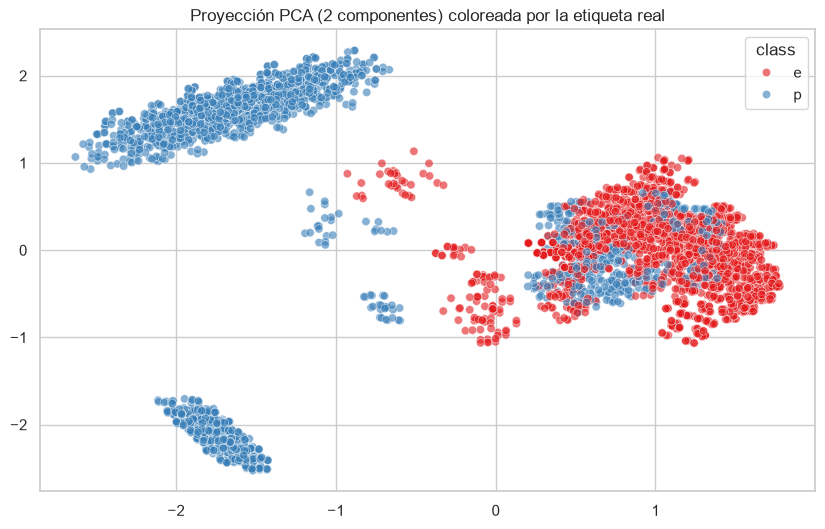

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)

# Representar en un scatterplot y poner en color las etiquetas de entrenamiento
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1],
                          hue=y_train, palette='Set1', alpha=0.6)
scatter.set_title('Proyección PCA (2 componentes) coloreada por la etiqueta real')

Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [16]:
# 1. Definir el clasificador y el numero de estimadores
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
# 2. Entrenar en train
rf.fit(X_train, y_train)
# 3. Calcular la precision sobre test
y_pred = rf.predict(X_test)
print(f"Precision de Random Forest sobre test: {accuracy_score(y_test, y_pred):.4f}")

Precision de Random Forest sobre test: 1.0000


Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [17]:
X_train.shape

(5443, 115)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

Text(0, 0.5, 'Precisión en test')

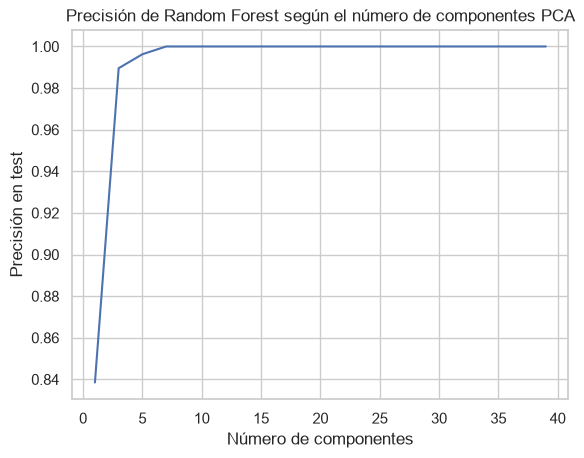

In [18]:
n_features = range(1, 40, 2)
scores = []

for n in n_features:
    # 1. Definir y ajustar PCA sobre X_train
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    X_train_pca_n = pca_n.fit_transform(X_train)
    X_test_pca_n = pca_n.transform(X_test)
    # 2. Entrenar Random Forest sobre los datos reducidos
    rf_pca = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_pca.fit(X_train_pca_n, y_train)
    # 3. Guardar el score en test
    scores.append(accuracy_score(y_test, rf_pca.predict(X_test_pca_n)))

sns.lineplot(x=list(n_features), y=scores)
plt.title('Precisión de Random Forest según el número de componentes PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Precisión en test')

A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

Text(0.5, 1.0, 't-SNE (muestra) coloreado por la etiqueta real')

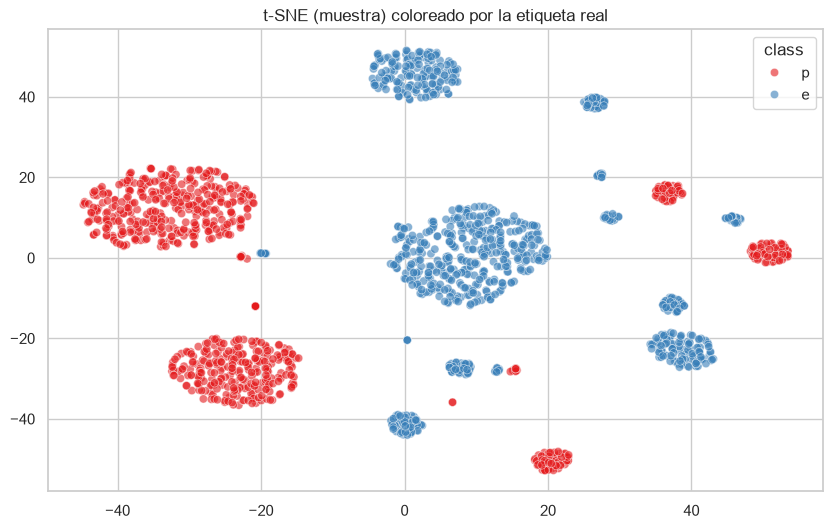

In [19]:
# 1. Tomar una muestra de X_train (t-SNE es lento)
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, test_size=0.7,
                                            random_state=RANDOM_STATE, stratify=y_train)
# 2. Definir TSNE(n_components=2, ...) y ajustar
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)
# 3. Pintar el embedding coloreado por la etiqueta
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample, palette='Set1', alpha=0.6)
plt.title('t-SNE (muestra) coloreado por la etiqueta real')

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [20]:
# Reducir X (one-hot completo) a 10 componentes con PCA -> X_red
X_red = PCA(n_components=10, random_state=RANDOM_STATE).fit_transform(X)
print(f"Dimensiones reducidas: {X_red.shape}")

Dimensiones reducidas: (8124, 10)


### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

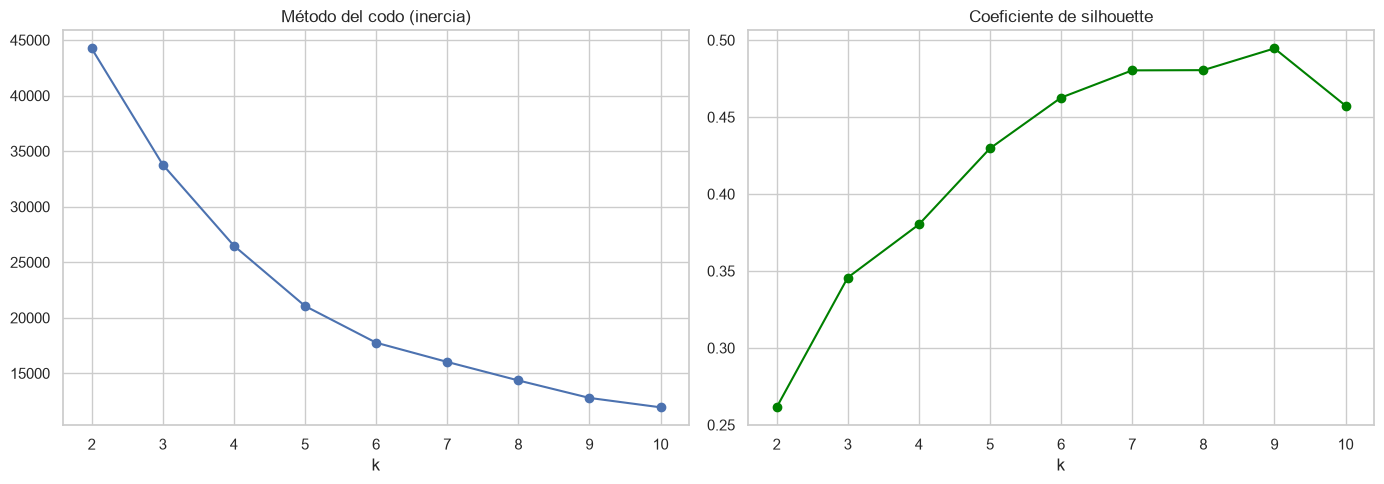

In [21]:
from sklearn.cluster import KMeans

k_values = range(2, 11)
inercias, silhouettes = [], []
for k in k_values:
    # Definir KMeans y ajustar sobre X_red
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_red)
    # Guardar la inercia (km.inertia_) y el silhouette_score
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_red, labels))

# Pintar las dos curvas (codo y silhouette)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(k_values), inercias, marker='o')
ax[0].set_title('Método del codo (inercia)')
ax[0].set_xlabel('k')
ax[1].plot(list(k_values), silhouettes, marker='o', color='green')
ax[1].set_title('Coeficiente de silhouette')
ax[1].set_xlabel('k')
plt.tight_layout()

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

ARI: 0.6171 | NMI: 0.5663


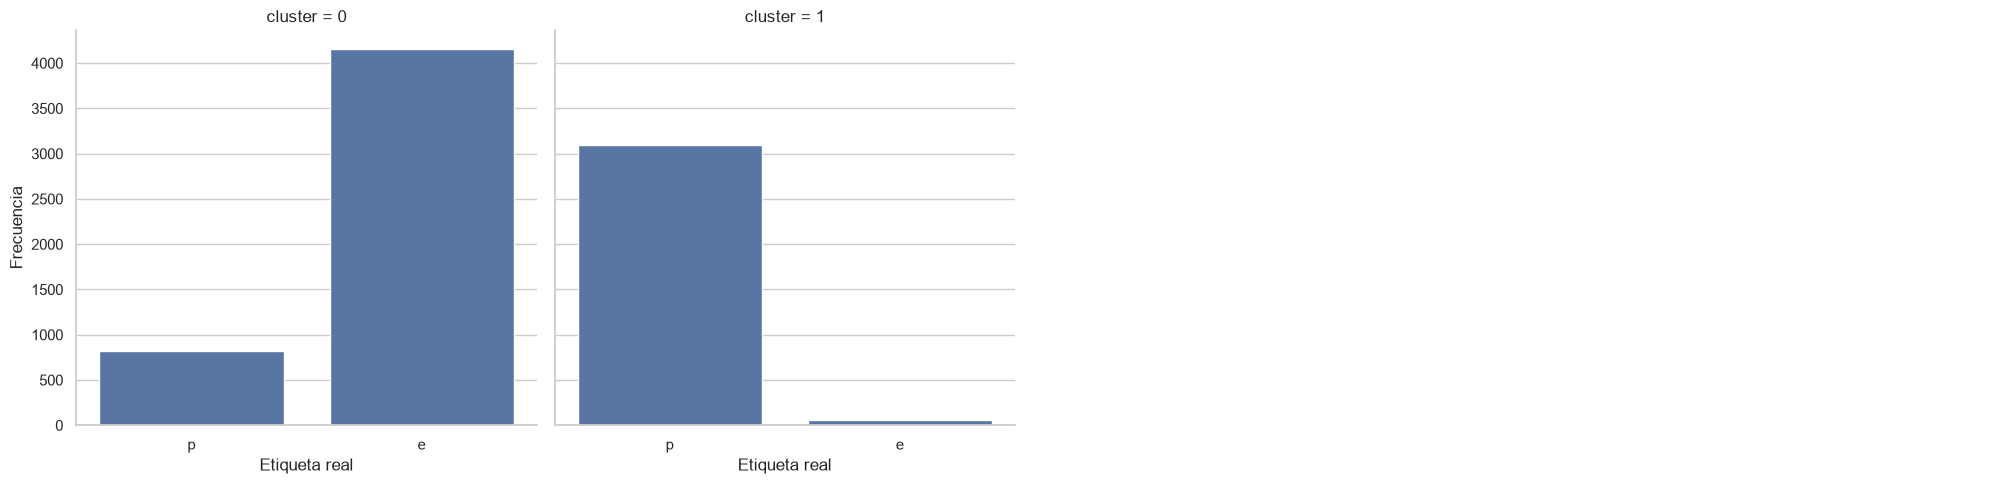

In [22]:
# Aprender KMeans con el k obtenido y preparar el catplot.
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_red)

data_plot = pd.DataFrame({'cluster': kmeans.labels_, 'label': y.values})

ax = sns.catplot(col='cluster', x='label', data=data_plot, kind='count', col_wrap=4)
ax.set_axis_labels('Etiqueta real', 'Frecuencia')

# Calcular ARI y NMI frente a y_bin
ari = adjusted_rand_score(y_bin, kmeans.labels_)
nmi = normalized_mutual_info_score(y_bin, kmeans.labels_)
print(f"ARI: {ari:.4f} | NMI: {nmi:.4f}")

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [23]:
# Definir una funcion evaluar(nombre, labels, X) que devuelva silhouette,
# davies_bouldin, calinski_harabasz y ARI.
def evaluar(nombre, labels, X):
    resultados = {'modelo': nombre}
    if len(np.unique(labels)) > 1:
        resultados['silhouette'] = silhouette_score(X, labels)
        resultados['davies_bouldin'] = davies_bouldin_score(X, labels)
        resultados['calinski_harabasz'] = calinski_harabasz_score(X, labels)
    else:
        resultados['silhouette'] = np.nan
        resultados['davies_bouldin'] = np.nan
        resultados['calinski_harabasz'] = np.nan
    resultados['ari'] = adjusted_rand_score(y_bin, labels)
    return resultados

# Aplicarla a KMeans, AgglomerativeClustering, GaussianMixture y DBSCAN
modelos = {
    'KMeans': KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_red),
    'Aglomerativo': AgglomerativeClustering(n_clusters=2).fit_predict(X_red),
    'GMM': GaussianMixture(n_components=2, random_state=RANDOM_STATE).fit_predict(X_red),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5).fit_predict(X_red),
}

# y montar una tabla (DataFrame) comparativa.
tabla_comparativa = pd.DataFrame(
    [evaluar(nombre, labels, X_red) for nombre, labels in modelos.items()]
)
tabla_comparativa

,modelo,silhouette,davies_bouldin,calinski_harabasz,ari
0,KMeans,0.261416,1.692939,2564.691274,0.617056
1,Aglomerativo,0.258872,1.696264,2503.624971,0.608952
2,GMM,0.257873,1.700914,2500.017463,0.598621
3,DBSCAN,0.331436,1.233514,1023.407016,0.021458


### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

Text(0, 0.5, 'Distancia')

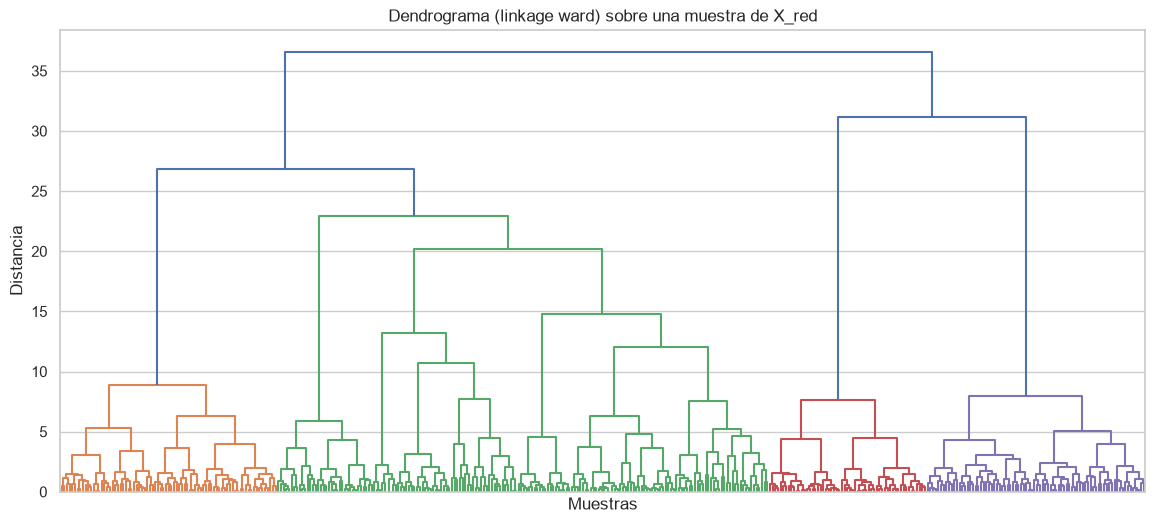

In [24]:
# 1. Tomar una muestra de X_red
X_red_sample, _ = train_test_split(X_red, test_size=0.95, random_state=RANDOM_STATE)
# 2. linkage(..., method='ward')
Z = linkage(X_red_sample, method='ward')
# 3. dendrogram(...) para visualizar la jerarquia
plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True)
plt.title('Dendrograma (linkage ward) sobre una muestra de X_red')
plt.xlabel('Muestras')
plt.ylabel('Distancia')

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [25]:
# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(X.shape[0], size=3000, replace=False)
X_bin_sample = X.iloc[idx]
X_red_sample_d = X_red[idx]
y_bin_sample = y_bin.iloc[idx]

db_euclidean = DBSCAN(eps=0.5, min_samples=5).fit(X_red_sample_d)
db_jaccard = DBSCAN(metric='jaccard', eps=0.4, min_samples=5).fit(X_bin_sample)

print('DBSCAN euclídea (sobre PCA) -> clusters:',
      len(set(db_euclidean.labels_)) - (1 if -1 in db_euclidean.labels_ else 0),
      '| ruido:', (db_euclidean.labels_ == -1).sum())
print('DBSCAN jaccard (sobre one-hot) -> clusters:',
      len(set(db_jaccard.labels_)) - (1 if -1 in db_jaccard.labels_ else 0),
      '| ruido:', (db_jaccard.labels_ == -1).sum())
print(f"ARI euclídea: {adjusted_rand_score(y_bin_sample, db_euclidean.labels_):.4f}")
print(f"ARI jaccard: {adjusted_rand_score(y_bin_sample, db_jaccard.labels_):.4f}")

DBSCAN euclídea (sobre PCA) -> clusters: 135 | ruido: 479
DBSCAN jaccard (sobre one-hot) -> clusters: 6 | ruido: 4
ARI euclídea: 0.0209
ARI jaccard: 0.3247


> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

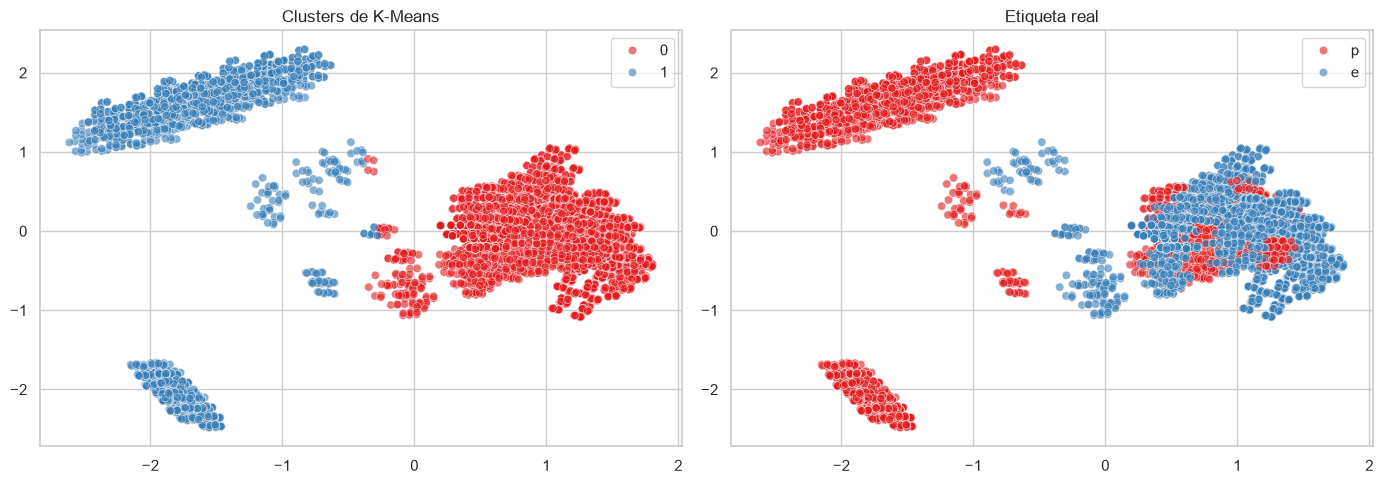

In [26]:
# Entrenar PCA(2) sobre X para representar.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X)

# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=kmeans.labels_, palette='Set1', ax=axes[0], alpha=0.6)
axes[0].set_title('Clusters de K-Means')
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y.values, palette='Set1', ax=axes[1], alpha=0.6)
axes[1].set_title('Etiqueta real')
plt.tight_layout()

Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

Número de anomalías: 407


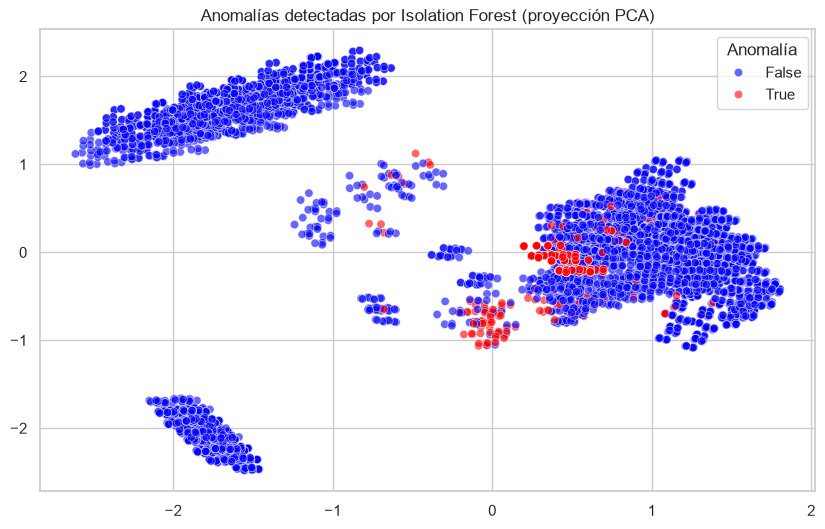

In [27]:
# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
iso_forest.fit(X_red)
# 2. predict -> -1 son anomalias
anomalias = iso_forest.predict(X_red)
print('Número de anomalías:', (anomalias == -1).sum())
# 3. Pintarlas sobre la proyeccion PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=(anomalias == -1), palette={False: 'blue', True: 'red'}, alpha=0.6)
plt.title('Anomalías detectadas por Isolation Forest (proyección PCA)')
plt.legend(title='Anomalía')

---
## Para ir más allá (opcional)

- **UMAP** (`pip install umap-learn`): alternativa a t-SNE, más rápida y preserva mejor la estructura global.
- **HDBSCAN** (`pip install hdbscan`): DBSCAN jerárquico que no necesita fijar `eps`.
- **Reglas de asociación** (`mlxtend`, Apriori/FP-Growth): muy naturales aquí por ser datos categóricos; permiten descubrir reglas tipo «si olor = X entonces venenosa».

## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.